<a href="https://colab.research.google.com/github/Zain506/MedCLIP-SAM/blob/main/notebooks/ImageSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Segmentation

**MedCLIP-SAM**
[Paper](https://arxiv.org/pdf/2403.20253)


**gScoreCAM**
[Paper](https://www.google.com/url?q=https%3A%2F%2Fopenaccess.thecvf.com%2Fcontent%2FACCV2022%2Fpapers%2FChen_gScoreCAM_What_objects_is_CLIP_looking_at_ACCV_2022_paper.pdf)

In [227]:
%pip install open-clip-torch -q

In [228]:
from google.colab import drive

drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Load BiomedCLIP

In [229]:
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import open_clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
weights_path = "/content/drive/MyDrive/colab/MedCLIP-SAM/biomedclip_weights.pth"
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

In [230]:
# We are looking for the final attention layer
# We place a hook in it to retrieve
modules = dict(model.named_modules())
print(modules[""]) # Full model. Other sublayers retrieved with keys

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

# Import Data

In [231]:
# Import data
from datasets import load_dataset
ds = load_dataset("adishourya/MEDPIX-ClinQA") # Same MedPIX dataset that fine-tuned MedCLIP
train_valid = ds["train"].train_test_split(test_size=0.1)
training = train_valid["train"].select(range(100))
test = train_valid["test"]

In [232]:
print(training)

Dataset({
    features: ['image_id', 'mode', 'case_id', 'question', 'answer'],
    num_rows: 100
})


dict_keys(['image_id', 'mode', 'case_id', 'question', 'answer'])
Talk about the condition:
The disease is discussed as: Leiomyosarcoma is the second most common primary retroperitoneal tumor in adults, and it is the most common venous neoplasm. This entity shows three growth patterns: 1) extravascular (62%), 2 intravascular (5%), and 3) both (33%). The clinical manifestations are: 1) large abdominal mass; symptoms consistent with venous thrombosis/Budd Chiari syndrome.  The most common radiologic feature is a large, partially necrotic soft-tissue mass in the retroperitoneum with or without extension into the inferior vena cava. Computed tomography and magnetic resonance imaging typically show a nonfatty, necrotic retroperitoneal mass and a vascular component when it is present.  

In this case, the tumor exhibited both extravascular and intravascular growth patterns, with a couple of images demonstrating a "beak sign" with both the IVC and the left renal vein strongly suggesting the or

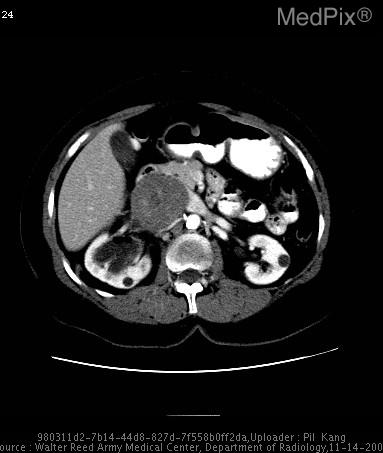

In [243]:
# Example image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
print(training[0].keys())
print(training[0]["question"])
print(training[0]["answer"])
image = training[0]["image_id"]
print(image.size) # 383x453 in 1 case
image

# Set up  hooks

In [234]:
model.eval()
model = model.to(device)
img = preprocess(image).unsqueeze(0).to(device)
print(img.shape) # 224x224 pixels, RGB

torch.Size([1, 3, 224, 224])


In [248]:
tmp = []

def attention(name):
  def hook(model, input, output):
    global tmp
    tmp = output
  return hook

handle = model.visual.transformer.resblocks[-1].attn.register_forward_hook(attention("attn"))

with torch.no_grad():
  _ = model.encode_image(img)

handle.remove()

In [260]:
print(tmp[0].shape)

cls = tmp[0][:, 0, :]
patches = tmp[0][:, 1:, :]
print(cls[0].shape)
print(patches[0].shape)
sim = patches @ cls.T
print(sim.shape)
print(sim)

torch.Size([1, 50, 768])
torch.Size([768])
torch.Size([49, 768])
torch.Size([1, 49, 1])
tensor([[[288.1703],
         [288.6746],
         [288.1119],
         [288.0557],
         [287.8551],
         [288.1022],
         [287.8157],
         [288.2103],
         [287.6800],
         [286.8041],
         [287.8138],
         [286.5626],
         [287.7401],
         [287.9303],
         [287.6313],
         [288.0305],
         [287.0813],
         [287.6102],
         [286.5429],
         [286.8134],
         [288.0811],
         [287.3963],
         [287.1206],
         [287.2755],
         [287.0615],
         [286.3550],
         [287.1382],
         [287.3970],
         [287.6313],
         [286.9847],
         [286.2750],
         [286.1482],
         [286.1447],
         [287.3750],
         [287.4233],
         [287.7010],
         [287.8264],
         [287.1364],
         [287.2751],
         [287.0856],
         [287.6634],
         [287.9034],
         [284.7544],
         